In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv("/content/drive/MyDrive/insurance.csv")

In [5]:
print(data.head())
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())
print(data.isnull().sum())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ K

In [6]:

data = data.dropna()

In [7]:
print(data.duplicated().sum())

1


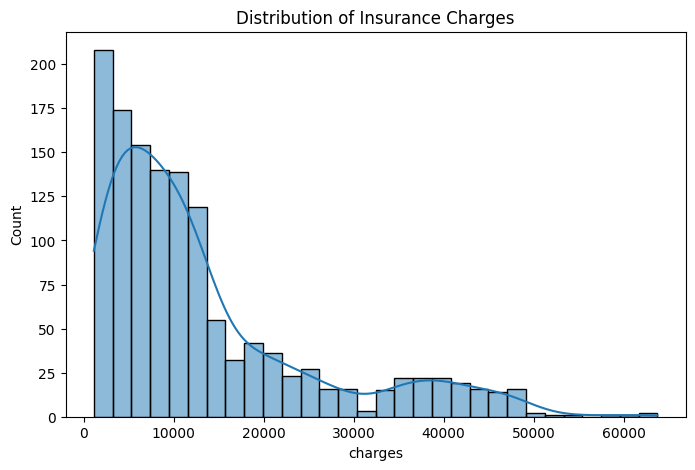

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(data['charges'], kde=True)

plt.title('Distribution of Insurance Charges')

plt.show()

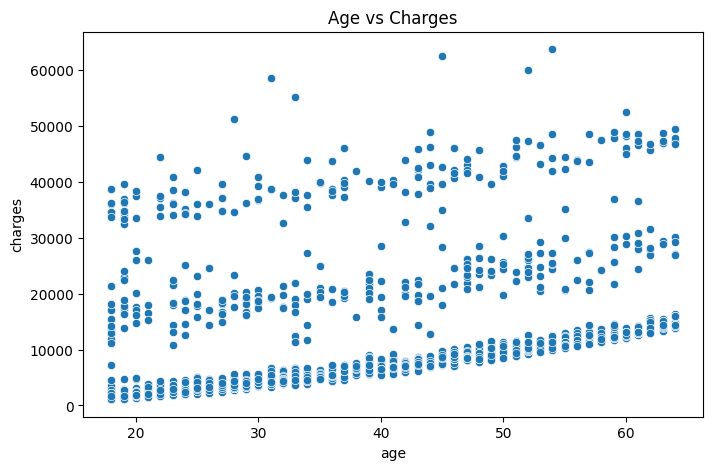

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='age', y='charges', data=data)

plt.title('Age vs Charges')

plt.show()

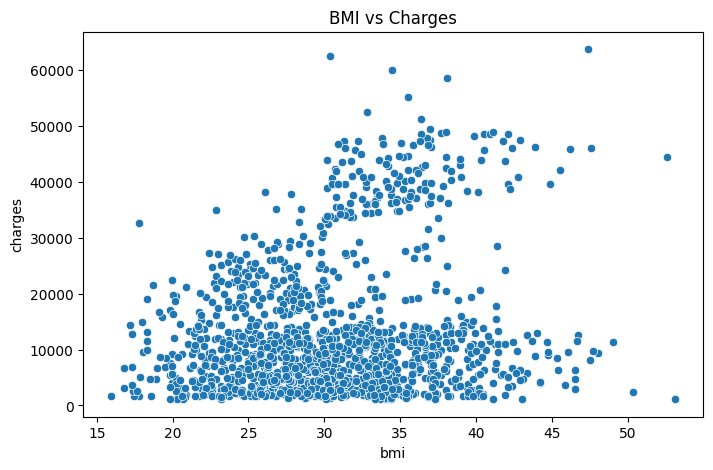

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='bmi', y='charges', data=data)

plt.title('BMI vs Charges')

plt.show()

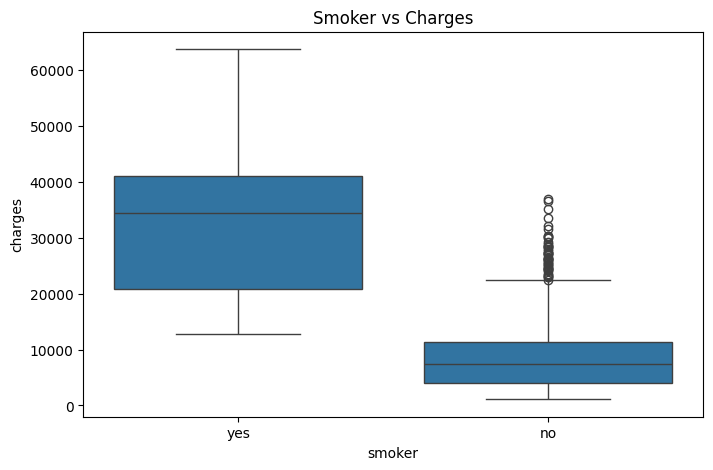

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x='smoker', y='charges', data=data)

plt.title('Smoker vs Charges')

plt.show()

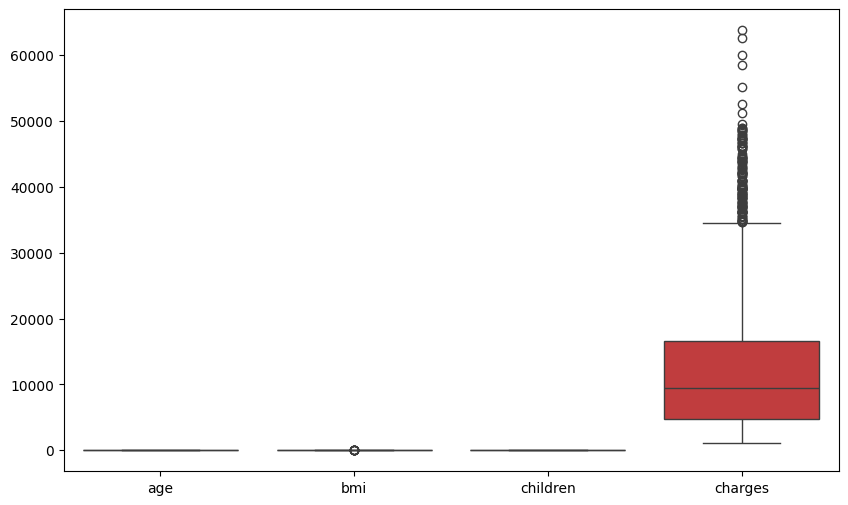

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(data=data[['age','bmi','children','charges']])

plt.show()

In [14]:
data = pd.get_dummies(data, drop_first=True)

print(data.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [15]:
X = data.drop('charges', axis=1)

y = data['charges']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [19]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


In [20]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 4181.194473753651


In [21]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE =", rmse)

RMSE = 5796.284659276274


In [22]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = 0.7835929767120722


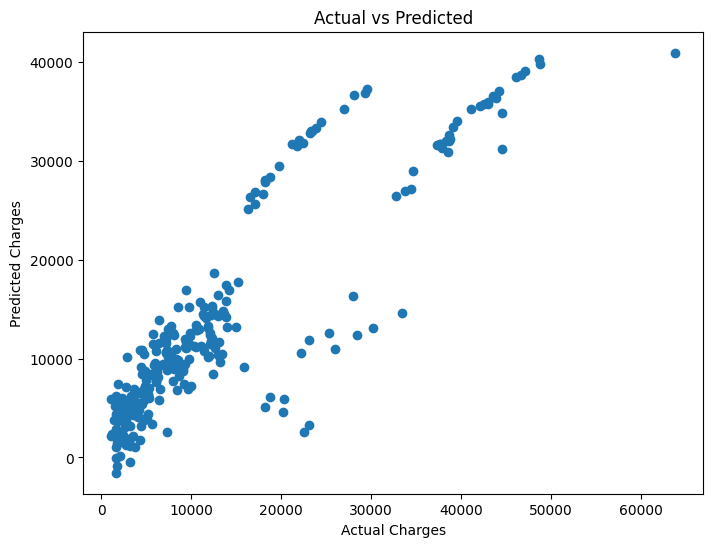

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Charges')

plt.ylabel('Predicted Charges')

plt.title('Actual vs Predicted')

plt.show()

In [24]:
coef = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

print(coef)

                  Coefficient
age               3614.975415
bmi               2036.228123
children           516.890247
sex_male            -9.293101
smoker_yes        9558.481409
region_northwest  -158.140981
region_southeast  -290.157047
region_southwest  -349.110678
